For this project, I am using run7722all_xyz.root that was produced by Arran using his custom Data processor that includes the muon hits (muon_paddle_hits) and the positions of each paddle in the meta tree.<br>

The data contains the data processed for the water PMTs also to link the muon hits with the PMT pulses.<br>


In [ ]:
# This block install some 3D plotting capability to your python install. 
# Uncomment and run once to install ipymp or plotly
#%pip install ipympl
#%pip install plotly

In [ ]:
# Let's print out the output tree.
import ROOT
f = ROOT.TFile.Open("../Data/run7722all_xyz.root")
output = f.Get("output")
output.Print()

The print out shows that the output tree has 353719 events. The useful variables for this analysis are
- muon_paddle_hits: 1s and 0s whether or not the paddle is hit out of the 134 total.
- digitNHits or digitNhitsCleaned: This is tell us how much energy is deposited in the water tank.
- digitCharge: Same as above but more direct correlation to energy.

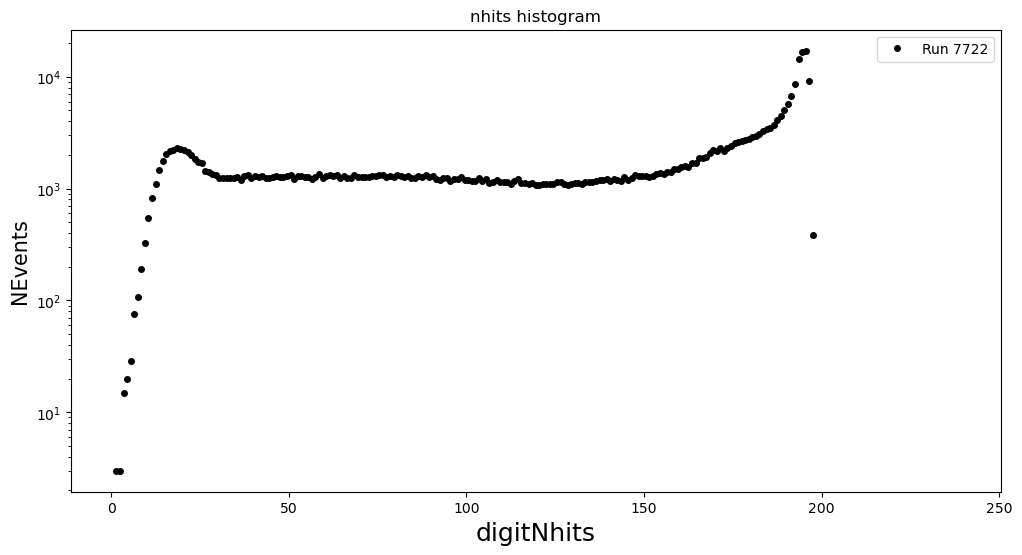

In [1]:
# This block just check if the digitNhits are valid for this dataset.
import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
# Create RDataFrame from the events tree of the input file.
rdf = ROOT.RDataFrame("output", "../Data/run7722all_xyz.root")
# Extract nhits values
digitNhits = rdf.AsNumpy(columns=["digitNhits"])["digitNhits"]
# Histogramming
digitNhits_counts, digitNhits_bins = np.histogram(digitNhits, bins=np.arange(0, 240, 1))
digitNhits_bin_centers = [(digitNhits_bins[i] + digitNhits_bins[i + 1]) / 2 for i in range(len(digitNhits_bins) - 1)]
# Plotting
plt.figure(figsize=(12, 6))
plt.title(f"nhits histogram")
plt.errorbar(digitNhits_bin_centers, digitNhits_counts,
             ls='', marker='o', mfc='black', ms=4, mec='black',
             ecolor='black', label="Run 7722")

plt.xlabel("digitNhits", fontsize=18)
plt.ylabel("NEvents", fontsize=15)
plt.yscale('log')
#plt.ylim(3000,250_000)
plt.legend()
plt.show()

This digitNhtis looks pretty normal for Muon Data. There's probably a lot of different events and noise mix into it but hopefully the Muon paddle data will help with this.

In [3]:
# This prints out the meta tree.
import ROOT
f = ROOT.TFile.Open("../Data/run7722all_xyz.root")
meta = f.Get("meta")
meta.Print()

******************************************************************************
*Tree    :meta      :                                                        *
*Entries :      164 : Total =         5003616 bytes  File  Size =     242827 *
*        :          : Tree compression factor =  24.40                       *
******************************************************************************
*Br    0 :runId     : runId/I                                                *
*Entries :      164 : Total  Size=       1285 bytes  File Size  =        196 *
*Baskets :        2 : Basket Size=      32000 bytes  Compression=   4.08     *
*............................................................................*
*Br    1 :runType   : runType/l                                              *
*Entries :      164 : Total  Size=       1961 bytes  File Size  =        200 *
*Baskets :        2 : Basket Size=      32000 bytes  Compression=   7.30     *
*...................................................

We need the values from muon_paddle_x,y,z.

In [ ]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

meta = ROOT.RDataFrame("meta", "../Data/run7722all_xyz.root")

#muon_paddle_x = meta.AsNumpy(columns=["muon_paddle_x"])
#print(muon_paddle_x)

#muon_paddle_y = meta.AsNumpy(columns=["muon_paddle_y"])
#print(muon_paddle_y)

muon_paddle_z = meta.AsNumpy(columns=["muon_paddle_z"])["muon_paddle_z"][0]
print(muon_paddle_z.shape)
#print(muon_paddle_z[0].shape)

muon_paddle_x,y,z seems to be 164x134 shape. The 134 is for the number of paddles, 164 is actually from the number of root/hdf5 files that were combined together.

What I want to do is to combine the position in the meta and hits from output together into a single array for analysis.

In [4]:
# Code to combine layer#, xyz positions of the paddle and the event by event hits.
# Layer is the row 0, xyz are row 1 to 3, hit data are 4 to NEvents+4
import ROOT
import numpy as np
import matplotlib.pyplot as plt

meta = ROOT.RDataFrame("meta", "../Data/run7722all_xyz.root")
# Get the xyz position, but we just need the 1st entry (hdf5 file).
x_pos = meta.AsNumpy(columns=["muon_paddle_x"])["muon_paddle_x"][0]
y_pos = meta.AsNumpy(columns=["muon_paddle_y"])["muon_paddle_y"][0]
z_pos = meta.AsNumpy(columns=["muon_paddle_z"])["muon_paddle_z"][0]
#print("x_pos shape:", x_pos.shape)
#print("y_pos shape:", y_pos.shape)
#print("z_pos shape:", z_pos.shape)

output = ROOT.RDataFrame("output", "../Data/run7722all_xyz.root")
# Get the muon_paddle_hit from the output tree.
# Convert from object array of event vectors to 2D array: NEvents x 134
muon_hits = np.stack(output.AsNumpy(["muon_paddle_hit"])["muon_paddle_hit"])

print("muon_hits shape:", muon_hits.shape)

# Put a value for the layers 
layer = np.zeros_like(z_pos, dtype=int) # defaults to 0
layer[np.isclose(z_pos, 2129.984)] = 1 # TopUpper-x
layer[np.isclose(z_pos, 2098.311)] = 2 # TopUpper+x
layer[np.isclose(z_pos, 1972.377)] = 3 # TopLower-y
layer[np.isclose(z_pos, 1940.704)] = 4 # TopLower+y
layer[np.isclose(z_pos, 699.896)] = 5 # Barrel+z
layer[np.isclose(z_pos, -398.908)] = 6 # Barrel-z
layer[np.isclose(z_pos, -1807.338)] = 7 # Bottom-y
layer[np.isclose(z_pos, -1839.012)] = 8 # Bottom+y

# Stack x, y, z as first 3 rows
muon_pos_hits = np.vstack([
    layer,
    x_pos,
    y_pos,
    z_pos,
    muon_hits
])

print("muon_hits_with_pos shape:", muon_pos_hits[0])

x_pos shape: (134,)
y_pos shape: (134,)
z_pos shape: (134,)
muon_hits shape: (353719, 134)
muon_hits_with_pos shape: [6. 5. 6. 3. 6. 5. 3. 4. 6. 5. 0. 0. 8. 2. 2. 3. 4. 8. 8. 8. 8. 8. 6. 6.
 6. 6. 6. 8. 8. 8. 8. 8. 6. 6. 6. 6. 6. 6. 6. 6. 3. 6. 3. 3. 3. 4. 4. 7.
 1. 1. 4. 0. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5. 7. 7. 7. 7. 7. 5. 5. 5. 5. 5.
 5. 5. 5. 4. 5. 4. 0. 3. 4. 0. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 6. 6.
 5. 5. 6. 6. 5. 5. 6. 6. 5. 5. 0. 0. 2. 6. 1. 5. 2. 6. 1. 5. 2. 2. 1. 1.
 2. 2. 1. 1. 2. 2. 1. 1. 3. 6. 4. 5. 0. 0.]


In [5]:
# Just checking the xyz for particular z position paddles
print(muon_pos_hits[1:4,np.where(np.isclose(muon_pos_hits[3,], -1839.012))[0]])

[[ 1270.     1016.      762.      508.      254.        0.    -1270.
  -1016.     -762.     -508.     -254.   ]
 [  549.402   549.402   549.402   549.402   549.402   549.402   549.402
    549.402   549.402   549.402   549.402]
 [-1839.012 -1839.012 -1839.012 -1839.012 -1839.012 -1839.012 -1839.012
  -1839.012 -1839.012 -1839.012 -1839.012]]


## Let's look for the easiest events first.
The muon passes through TopUpper, TopLower and Bottom. Assuming the muon is travel almost straight, the three paddle should have a path that can be intersected by a straight line.<br>

Let's filter for the events that has 1 hit on each TopUpper, TopLower and Bottom and no hits on the barrel.

In [24]:
# Get columns from layer info
TopUpper = np.where((muon_pos_hits[0] == 1) | (muon_pos_hits[0] == 2))[0]
TopLower = np.where((muon_pos_hits[0] == 3) | (muon_pos_hits[0] == 4))[0]
Bottom = np.where((muon_pos_hits[0] == 7) | (muon_pos_hits[0] == 8))[0]
Barrel = np.where((muon_pos_hits[0] == 5) | (muon_pos_hits[0] == 6))[0]

#print("TopUpper columns:", TopUpper)
#print("TopLower columns:", TopLower)

# Count hits only in the selected layer groups
top_upper_hits = np.count_nonzero(muon_paddle_hit[:, TopUpper] == 1, axis=1)
top_lower_hits = np.count_nonzero(muon_paddle_hit[:, TopLower] == 1, axis=1)
bottom_hits = np.count_nonzero(muon_paddle_hit[:, Bottom] == 1, axis=1)
barrel_hits = np.count_nonzero(muon_paddle_hit[:, Barrel] == 1, axis=1)

for event_number, upper_count, lower_count, bottom_count, barrel_count in zip(
    range(len(muon_pos_hits[4:])),
    top_upper_hits,
    top_lower_hits,
    bottom_hits,
    barrel_hits
):
    if upper_count == 1 and lower_count == 1 and bottom_count == 1 and barrel_count == 0:
        print(
            f"Event {event_number}: "
            f"TopUpper = {upper_count} hits, "
            f"TopLower = {lower_count} hits"
            f"Bottom = {bottom_count} hits"
            f"Barrel = {barrel_count} hits"
        
        )

Event 38: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 331: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 526: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 677: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 856: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1044: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1050: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1099: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1214: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1456: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1733: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1775: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1 hitsBarrel = 0 hits
Event 1906: TopUpper = 1 hits, TopLower = 1 hitsBottom = 1

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib qt
# Use Qt backend for smoother 3D rotation
# Run this once in a separate notebook cell if needed:
# %matplotlib qt

EVENTNUM = 3049


def draw_box(ax, center, size, alpha=0.35):
    """
    Draw a rectangular box centered at center=(x,y,z)
    with full dimensions size=(dx,dy,dz).
    """
    cx, cy, cz = center
    dx, dy, dz = size

    x0, x1 = cx - dx/2, cx + dx/2
    y0, y1 = cy - dy/2, cy + dy/2
    z0, z1 = cz - dz/2, cz + dz/2

    vertices = np.array([
        [x0, y0, z0],
        [x1, y0, z0],
        [x1, y1, z0],
        [x0, y1, z0],
        [x0, y0, z1],
        [x1, y0, z1],
        [x1, y1, z1],
        [x0, y1, z1],
    ])

    faces = [
        [vertices[0], vertices[1], vertices[2], vertices[3]],  # bottom
        [vertices[4], vertices[5], vertices[6], vertices[7]],  # top
        [vertices[0], vertices[1], vertices[5], vertices[4]],  # side
        [vertices[2], vertices[3], vertices[7], vertices[6]],  # side
        [vertices[1], vertices[2], vertices[6], vertices[5]],  # side
        [vertices[0], vertices[3], vertices[7], vertices[4]],  # side
    ]

    box = Poly3DCollection(
        faces,
        alpha=alpha,
        edgecolor="k",
        linewidths=0.8
    )

    ax.add_collection3d(box)


# Rows in muon_pos_hits:
# row 0 = layer
# row 1 = x_pos
# row 2 = y_pos
# row 3 = z_pos
# row 4 + EVENTNUM = hits for that event

event_hit_row = 4 + EVENTNUM

hit_columns = np.where(muon_pos_hits[event_hit_row] == 1)[0]

print(f"Event {EVENTNUM}")
print("hit columns:", hit_columns)
print("number of hits:", len(hit_columns))

fig = plt.figure(figsize=(10, 11))
ax = fig.add_subplot(111, projection="3d")

for col in hit_columns:
    layer_value = int(muon_pos_hits[0, col])

    x = muon_pos_hits[1, col]
    y = muon_pos_hits[2, col]
    z = muon_pos_hits[3, col]

    print(f"  col {col}: layer={layer_value}, x={x}, y={y}, z={z}")

    if layer_value == 1:
        draw_box(ax, center=(x, y, z), size=(210, 1250, 10), alpha=0.35)
    elif layer_value == 2:
        draw_box(ax, center=(x, y, z), size=(210, 1250, 10), alpha=0.35)
    elif layer_value == 3:
        draw_box(ax, center=(x, y, z), size=(1250, 210, 10), alpha=0.35)    
    elif layer_value == 4:
        draw_box(ax, center=(x, y, z), size=(1250, 210, 10), alpha=0.35)
    elif layer_value == 5:
        draw_box(ax, center=(x, y, z), size=(100, 100, 1250), alpha=0.35)
    elif layer_value == 6:
        draw_box(ax, center=(x, y, z), size=(100, 100, 1250), alpha=0.35)
    elif layer_value == 7:
        draw_box(ax, center=(x, y, z), size=(1250, 210, 10), alpha=0.35)    
    elif layer_value == 8:
        draw_box(ax, center=(x, y, z), size=(1250, 210, 10), alpha=0.35)
    else:
        ax.scatter(x, y, z, s=80)

    ax.text(x, y, z, layer_value, fontsize=9)


ax.set_xlabel("x_pos")
ax.set_ylabel("y_pos")
ax.set_zlabel("z_pos")
ax.set_title(f"Event {EVENTNUM}: Muon Hits with Layer #")

ax.set_xlim(-1600, 1600)
ax.set_ylim(-1600, 1600)
ax.set_zlim(-2200, 2200)

ax.set_box_aspect((3200, 3200, 4400))

plt.show()

Event 3049
hit columns: [ 50  65 127]
number of hits: 3
  col 50: layer=4, x=-488.95, y=549.402, z=1940.704
  col 65: layer=7, x=-508.0, y=-549.402, z=-1807.338
  col 127: layer=1, x=-549.402, y=273.05, z=2129.984


## Some Possible Pass Through Events.
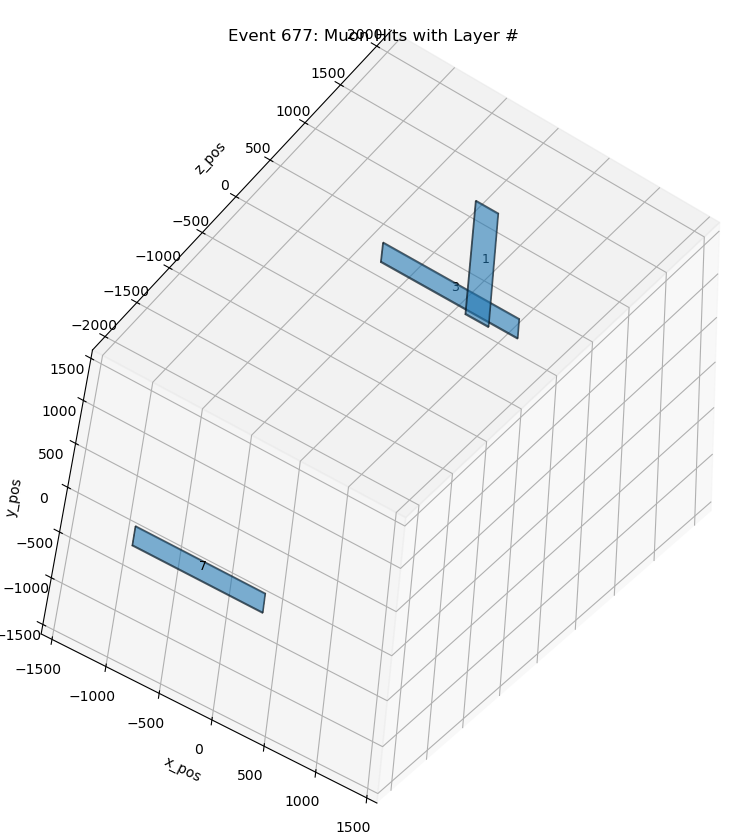
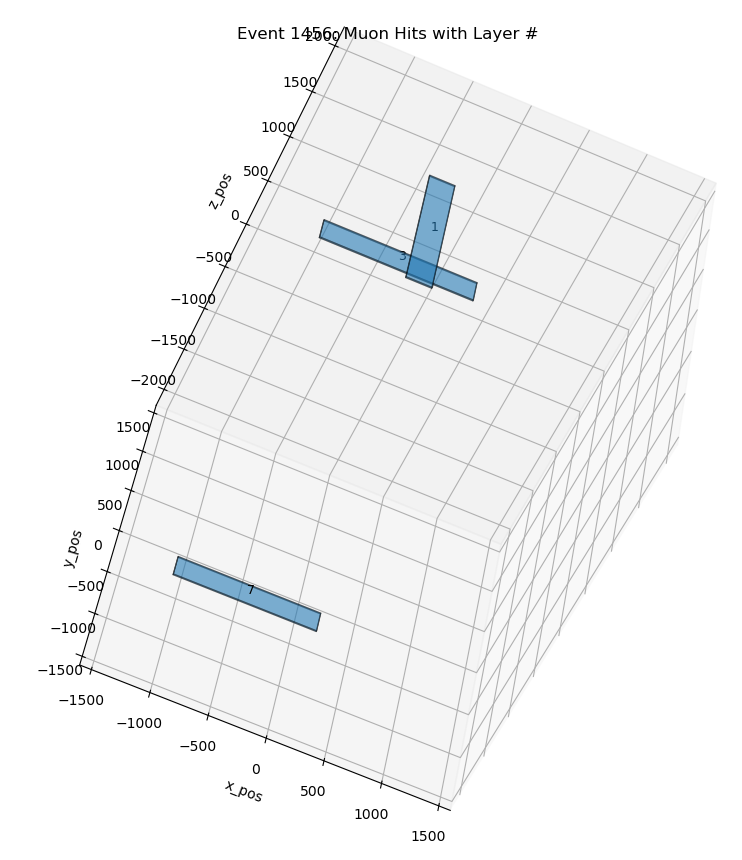
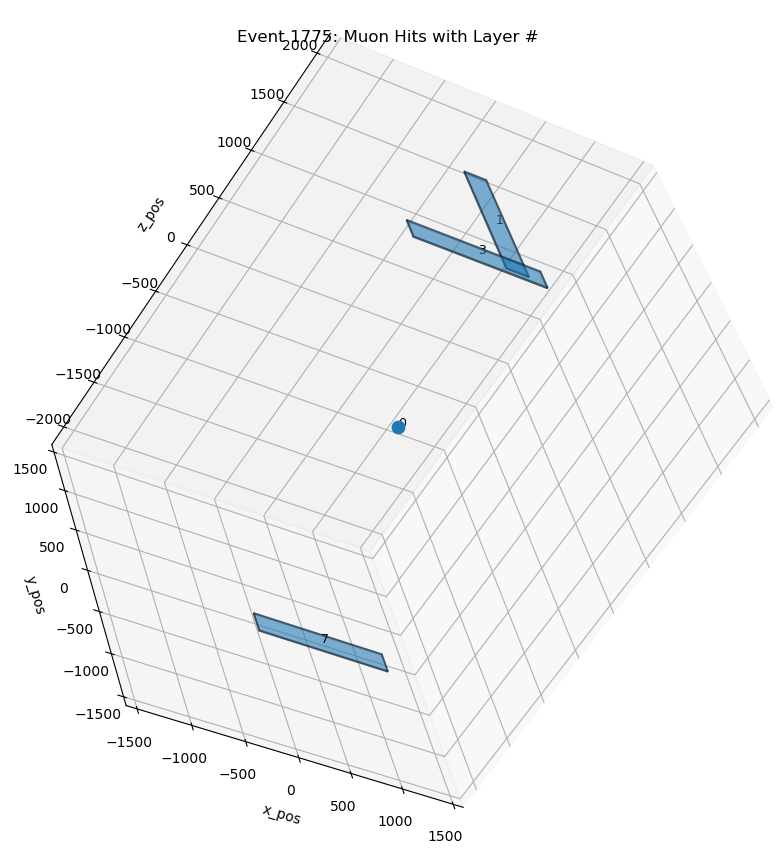
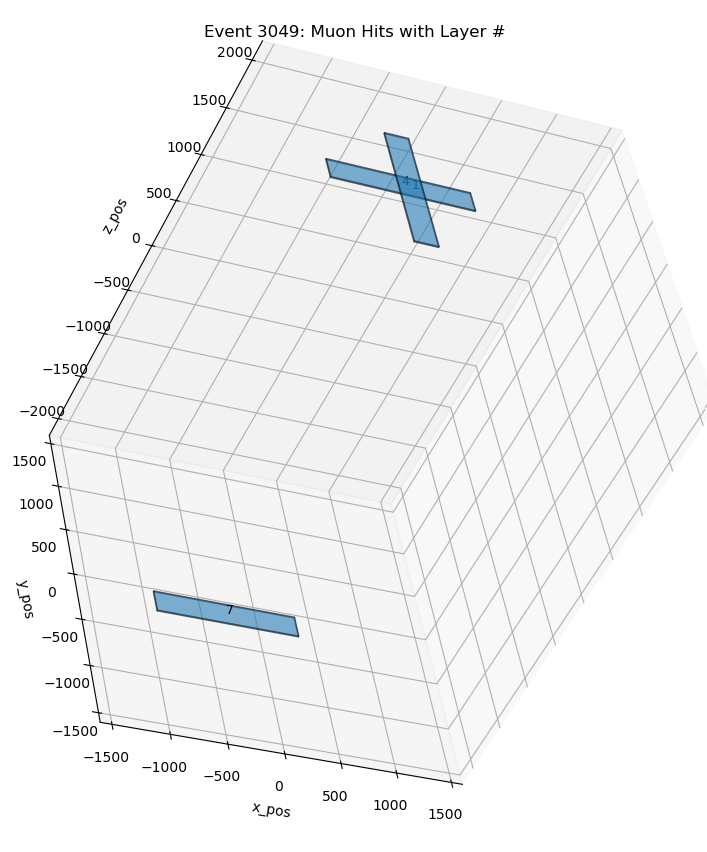
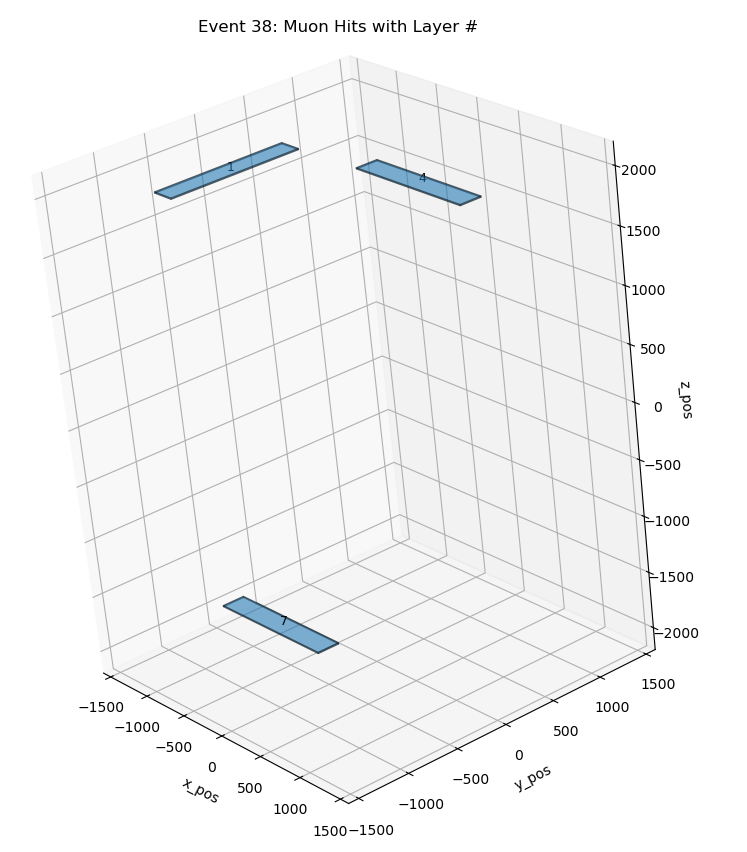
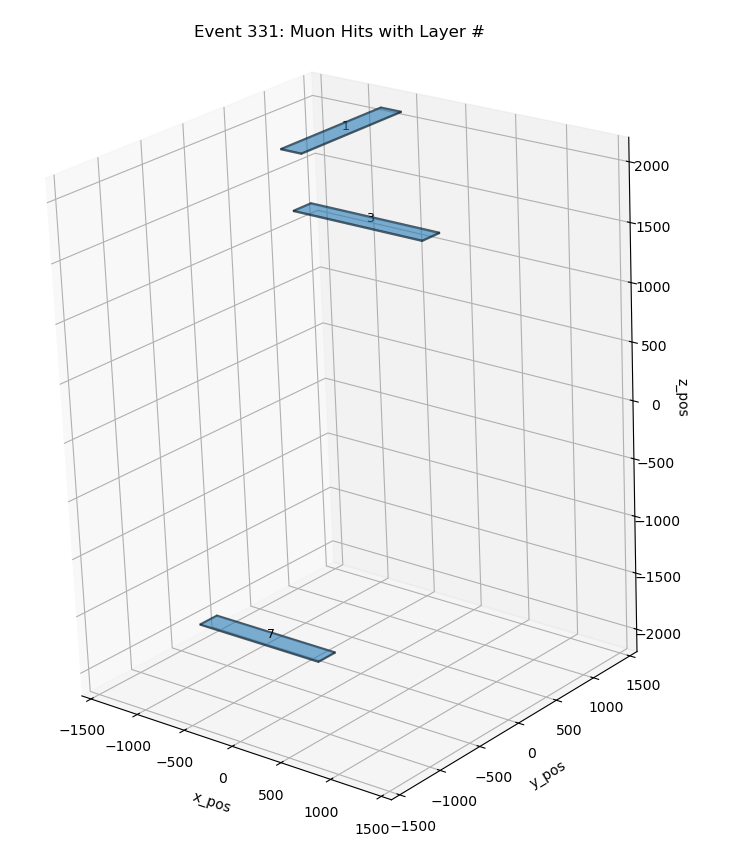
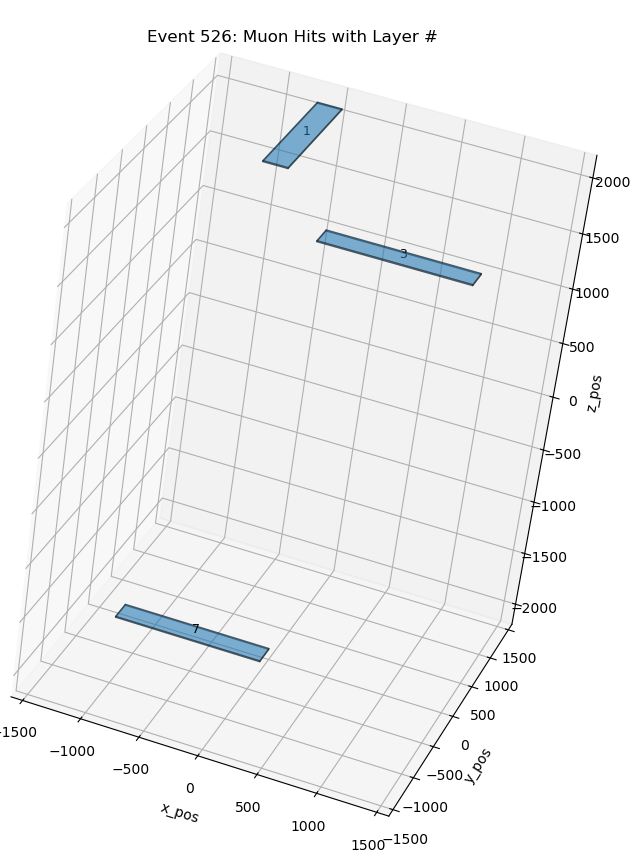